# ia-tenis — Exploración de resultados ATP

Este notebook analiza el dataset de features generado por el pipeline y los resultados del backtest walk-forward (2000–2023).  
Fuente de datos: **TML-Database** (Tennismylife) — 109 k partidos ATP 1990–2023.

**Ejecutar con el kernel `tenis-env`** (desde cualquier directorio).

In [1]:
import os, sys
from pathlib import Path

# Fijar CWD en la raíz del proyecto (funciona tanto desde notebooks/ como desde la raíz)
_nb_dir = Path('__file__').resolve().parent if '__file__' in dir() else Path.cwd()
_root = _nb_dir if (_nb_dir / 'src').exists() else _nb_dir.parent
os.chdir(_root)
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

print(f'CWD: {Path.cwd()}')

CWD: D:\ia-tenis


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve

from src.backtest.walkforward import walk_forward_backtest

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 120

FEATURE_COLS = [
    'elo_diff', 'elo_prob', 'rank_diff',
    'form_diff', 'surface_form_diff', 'h2h_rate', 'rest_diff'
]

## 1. Cargar datos

In [3]:
df = pd.read_csv('data/processed/atp_features.csv', parse_dates=['match_date'])
print(f'Partidos: {len(df):,}  |  Años: {df["year"].min()}–{df["year"].max()}  |  Features: {len(FEATURE_COLS)}')
df.head(3)

Partidos: 109,086  |  Años: 1990–2023  |  Features: 7


,match_date,year,winner,loser,surface,elo_diff,elo_prob,rank_diff,form_diff,surface_form_diff,h2h_rate,rest_diff,outcome,is_mirror
0,1990-01-01,1990,Sergi Bruguera,Per Henricsson,hard,0.0,0.5,257.0,0.0,0.0,0.5,0.0,1,False
1,1990-01-01,1990,Gilad Bloom,Magnus Gustafsson,hard,0.0,0.5,-90.0,0.0,0.0,0.5,0.0,1,False
2,1990-01-01,1990,Lars-Anders Wahlgren,Kelly Evernden,hard,0.0,0.5,-83.0,0.0,0.0,0.5,0.0,1,False


In [4]:
# Añadir mirrors para backtest (necesario para LR balanceada)
mirror = df.copy()
for col in ('elo_diff', 'rank_diff', 'form_diff', 'surface_form_diff', 'rest_diff'):
    mirror[col] = -mirror[col]
mirror['elo_prob'] = 1.0 - mirror['elo_prob']
mirror['h2h_rate'] = 1.0 - mirror['h2h_rate']
mirror['outcome'] = 0
mirror['is_mirror'] = True
full_df = pd.concat([df, mirror], ignore_index=True)
print(f'Dataset con mirrors: {len(full_df):,} filas')

Dataset con mirrors: 218,172 filas


## 2. Distribución de partidos

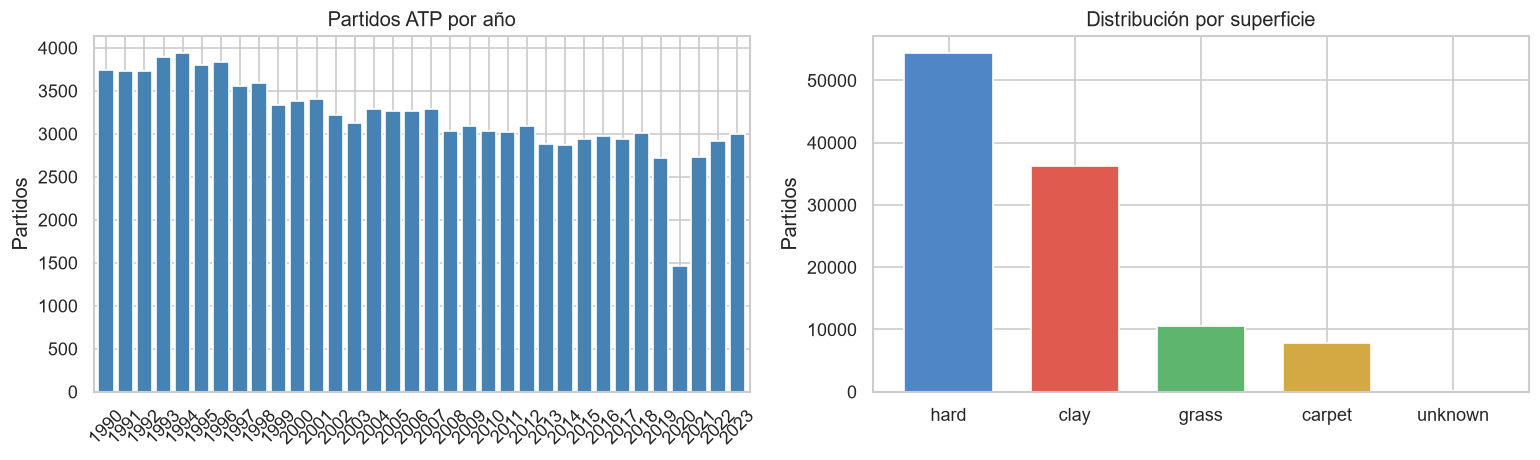

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Partidos por año
by_year = df.groupby('year').size()
by_year.plot(kind='bar', ax=axes[0], color='steelblue', width=0.8)
axes[0].set_title('Partidos ATP por año')
axes[0].set_xlabel('')
axes[0].set_ylabel('Partidos')
axes[0].tick_params(axis='x', rotation=45)

# Partidos por superficie
surf_counts = df['surface'].value_counts()
surf_counts.plot(kind='bar', ax=axes[1],
    color=['#4f86c6','#e05a4f','#5eb56e','#d4a843','#aaa'], width=0.7)
axes[1].set_title('Distribución por superficie')
axes[1].set_xlabel('')
axes[1].set_ylabel('Partidos')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 3. Análisis de features Elo

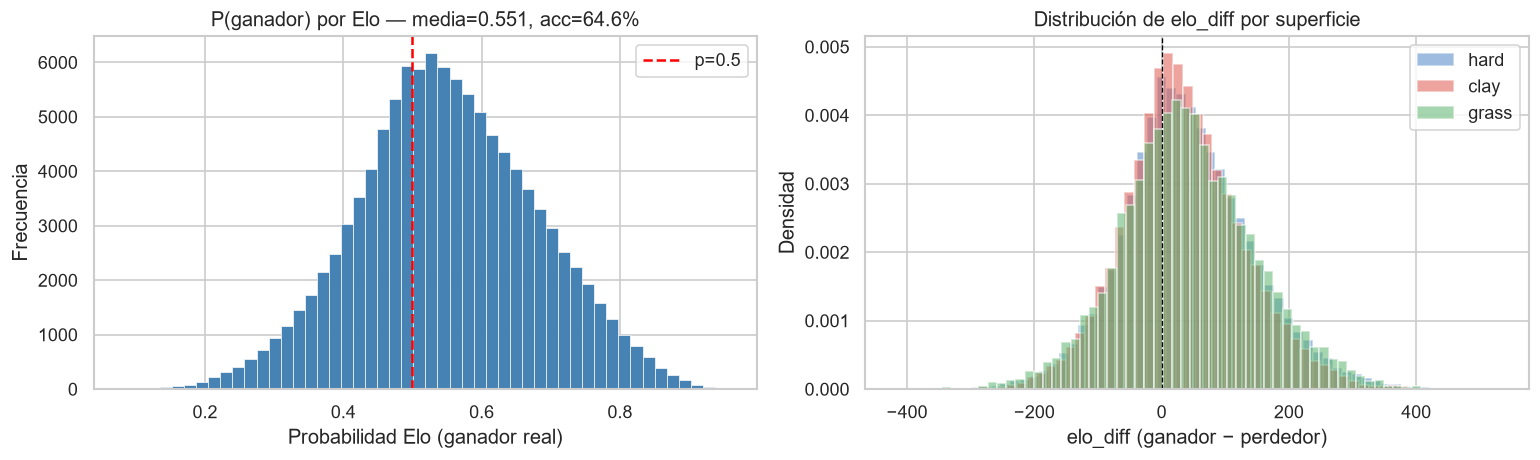

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribución de elo_prob (ganador real)
axes[0].hist(df['elo_prob'], bins=50, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].axvline(0.5, color='red', linestyle='--', label='p=0.5')
mean_p = df['elo_prob'].mean()
pct_correct = (df['elo_prob'] > 0.5).mean() * 100
axes[0].set_title(f'P(ganador) por Elo — media={mean_p:.3f}, acc={pct_correct:.1f}%')
axes[0].set_xlabel('Probabilidad Elo (ganador real)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# elo_diff por superficie
for surf, col in [('hard','#4f86c6'), ('clay','#e05a4f'), ('grass','#5eb56e')]:
    sub = df[df['surface'] == surf]['elo_diff']
    axes[1].hist(sub, bins=60, alpha=0.55, color=col, label=surf, density=True)
axes[1].axvline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_title('Distribución de elo_diff por superficie')
axes[1].set_xlabel('elo_diff (ganador − perdedor)')
axes[1].set_ylabel('Densidad')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Correlación entre features

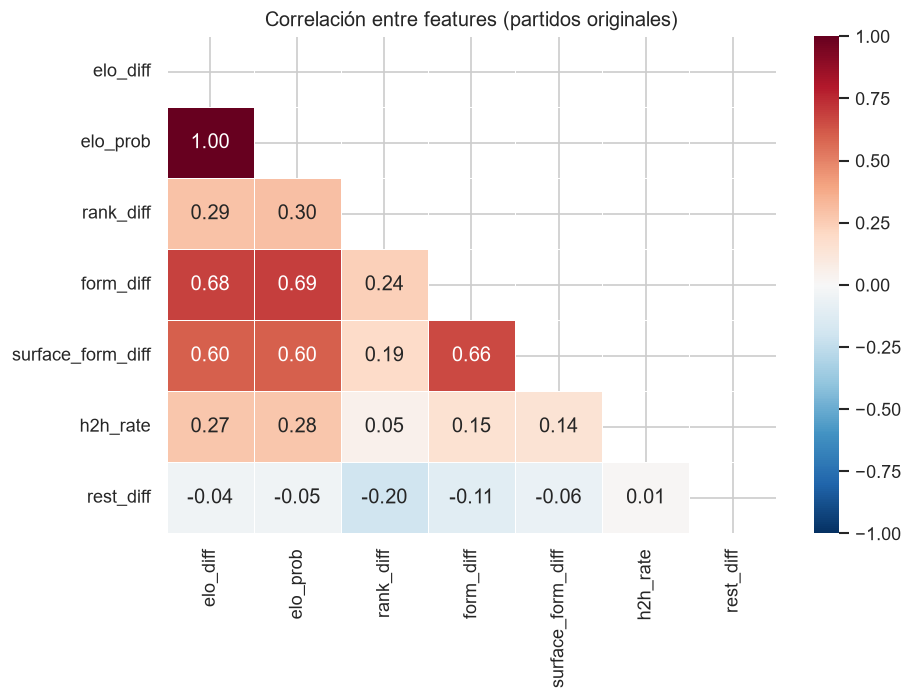

In [7]:
corr = df[FEATURE_COLS].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    vmin=-1, vmax=1, center=0, linewidths=0.5, ax=ax
)
ax.set_title('Correlación entre features (partidos originales)')
plt.tight_layout()
plt.show()

## 5. Backtest walk-forward

In [8]:
results = walk_forward_backtest(full_df, warmup_years=10)
res_df = pd.DataFrame(results).T.sort_index()
res_df.index.name = 'year'
res_df.index = res_df.index.astype(int)
print(f'Años evaluados: {len(res_df)}')
res_df[['accuracy','elo_only_accuracy','log_loss','elo_only_log_loss','brier_score','n_matches']].round(4)

Años evaluados: 24


,accuracy,elo_only_accuracy,log_loss,elo_only_log_loss,brier_score,n_matches
year,,,,,,
2000,0.6723,0.6459,0.6283,0.6387,0.2137,3378.0
2001,0.6625,0.6325,0.6155,0.6358,0.2111,3404.0
2002,0.6660,0.6334,0.6167,0.6370,0.2115,3213.0
2003,0.6742,0.6451,0.6145,0.6304,0.2096,3125.0
2004,0.6749,0.6414,0.6026,0.6329,0.2070,3288.0
2005,0.6874,0.6666,0.5895,0.6192,0.2011,3263.0
2006,0.6866,0.6578,0.6007,0.6167,0.2033,3267.0
2007,0.6865,0.6597,0.5868,0.6188,0.2007,3285.0
2008,0.6964,0.6601,0.5781,0.6164,0.1973,3030.0


## 6. Accuracy y Log-loss por año

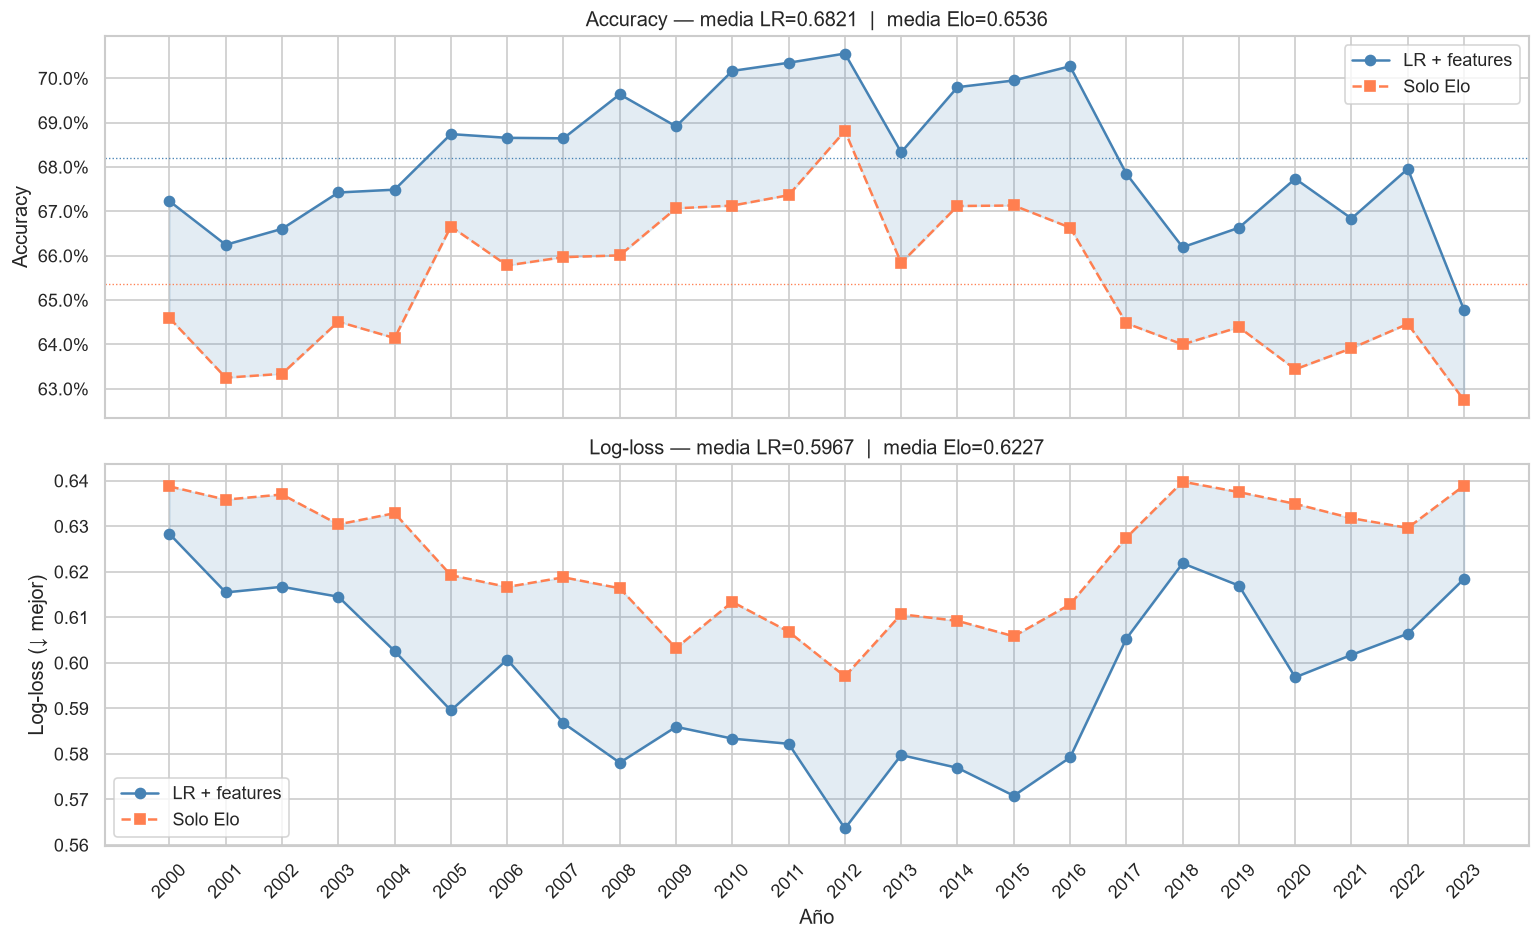

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
years = res_df.index

# Accuracy
axes[0].plot(years, res_df['accuracy'],          marker='o', color='steelblue', label='LR + features')
axes[0].plot(years, res_df['elo_only_accuracy'], marker='s', color='coral',     label='Solo Elo', linestyle='--')
axes[0].fill_between(years, res_df['elo_only_accuracy'], res_df['accuracy'], alpha=0.15, color='steelblue')
axes[0].axhline(res_df['accuracy'].mean(),          color='steelblue', linewidth=0.8, linestyle=':')
axes[0].axhline(res_df['elo_only_accuracy'].mean(), color='coral',     linewidth=0.8, linestyle=':')
axes[0].set_ylabel('Accuracy')
axes[0].set_title(f'Accuracy — media LR={res_df["accuracy"].mean():.4f}  |  media Elo={res_df["elo_only_accuracy"].mean():.4f}')
axes[0].legend()
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=1))

# Log-loss
axes[1].plot(years, res_df['log_loss'],          marker='o', color='steelblue', label='LR + features')
axes[1].plot(years, res_df['elo_only_log_loss'], marker='s', color='coral',     label='Solo Elo', linestyle='--')
axes[1].fill_between(years, res_df['log_loss'], res_df['elo_only_log_loss'], alpha=0.15, color='steelblue')
axes[1].set_ylabel('Log-loss (↓ mejor)')
axes[1].set_xlabel('Año')
axes[1].set_title(f'Log-loss — media LR={res_df["log_loss"].mean():.4f}  |  media Elo={res_df["elo_only_log_loss"].mean():.4f}')
axes[1].legend()

for ax in axes:
    ax.set_xticks(years)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 7. Importancia de features (coeficientes LR, último año)

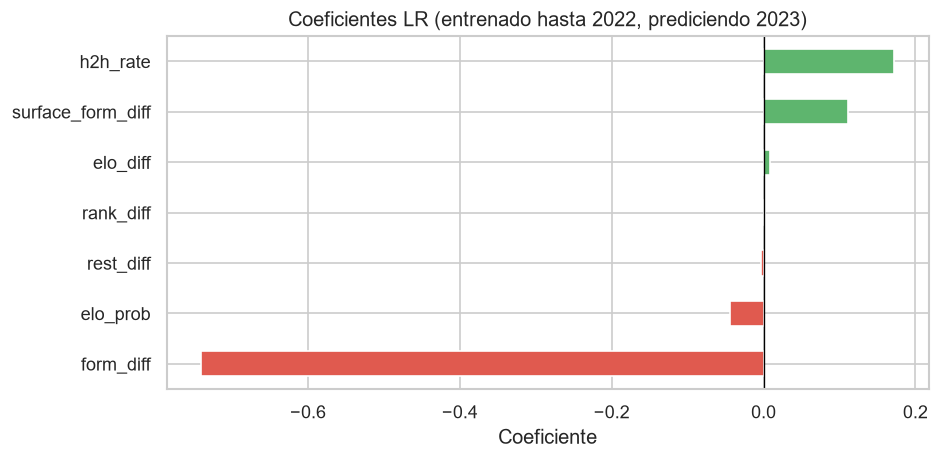

form_diff           -0.740766
elo_prob            -0.044272
rest_diff           -0.003252
rank_diff            0.001819
elo_diff             0.007863
surface_form_diff    0.111292
h2h_rate             0.171957


In [10]:
last_year = int(res_df.index[-1])
train_all = full_df[full_df['year'] < last_year]
test_last  = df[df['year'] == last_year]

clf = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
clf.fit(train_all[FEATURE_COLS].fillna(0), train_all['outcome'])

coefs = pd.Series(clf.coef_[0], index=FEATURE_COLS).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#e05a4f' if c < 0 else '#5eb56e' for c in coefs]
coefs.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title(f'Coeficientes LR (entrenado hasta {last_year-1}, prediciendo {last_year})')
ax.set_xlabel('Coeficiente')
plt.tight_layout()
plt.show()

print(coefs.to_string())

## 8. Accuracy por superficie

       accuracy  elo_only_accuracy  log_loss        n
hard     0.6893             0.6590    0.5870  39127.0
clay     0.6680             0.6441    0.6080  23272.0
grass    0.7187             0.6613    0.5963   7375.0


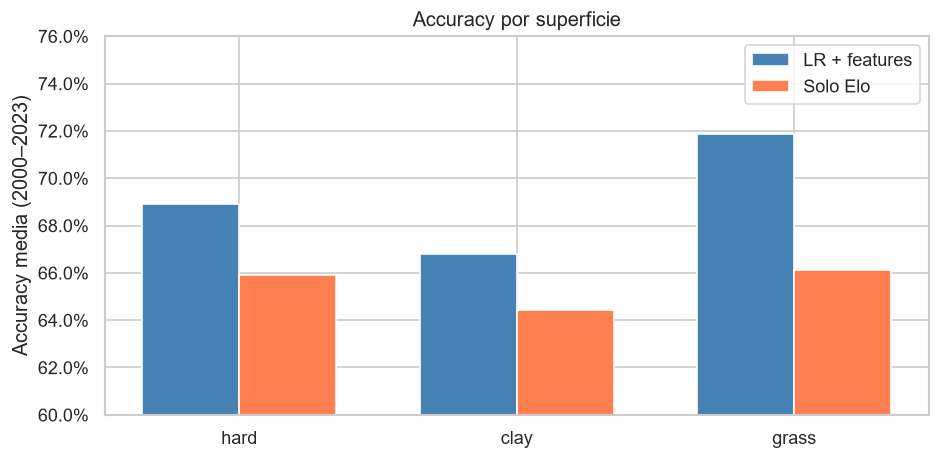

In [11]:
surfaces_main = ['hard', 'clay', 'grass']
surf_results = {}

for surf in surfaces_main:
    sub = full_df[full_df['surface'] == surf]
    r = walk_forward_backtest(sub, warmup_years=10)
    if r:
        surf_results[surf] = {
            'accuracy':          np.mean([m['accuracy']          for m in r.values()]),
            'elo_only_accuracy': np.mean([m['elo_only_accuracy']  for m in r.values()]),
            'log_loss':          np.mean([m['log_loss']           for m in r.values()]),
            'n':                 sum(m['n_matches'] for m in r.values()),
        }

surf_df = pd.DataFrame(surf_results).T
print(surf_df.round(4))

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(surfaces_main))
w = 0.35
ax.bar(x - w/2, surf_df.loc[surfaces_main, 'accuracy'],          width=w, label='LR + features', color='steelblue')
ax.bar(x + w/2, surf_df.loc[surfaces_main, 'elo_only_accuracy'], width=w, label='Solo Elo',      color='coral')
ax.set_xticks(x)
ax.set_xticklabels(surfaces_main)
ax.set_ylabel('Accuracy media (2000–2023)')
ax.set_title('Accuracy por superficie')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=1))
ax.legend()
ax.set_ylim(0.60, 0.76)
plt.tight_layout()
plt.show()

## 9. Jugadores con mayor Elo al cierre de 2023
*(Reconstruye EloSystem procesando todos los partidos — tarda ~30 s)*

In [12]:
from src.data.loader import load_atp_matches
from src.models.elo import EloSystem
from src.features.engineering import FeatureBuilder
from src.backtest.walkforward import build_match_features

print('Reconstruyendo EloSystem (1990–2023)...')
raw  = load_atp_matches(1990, 2023)
elo  = EloSystem()
fb   = FeatureBuilder()
_    = build_match_features(raw, elo, fb)
print(f'Listo. Jugadores en sistema: {len(elo.general_ratings):,}')

Reconstruyendo EloSystem (1990–2023)...


Listo. Jugadores en sistema: 3,613


In [13]:
# Top 20 Elo general
top_gen = (
    pd.Series(elo.general_ratings, name='elo_general')
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)
top_gen.columns = ['jugador', 'elo_general']
top_gen

,jugador,elo_general
0,Novak Djokovic,1912.821557
1,Carlos Alcaraz,1844.343567
2,Jannik Sinner,1836.734314
3,Daniil Medvedev,1808.064124
4,Robin Soderling,1794.633557
5,Patrick Rafter,1759.086979
6,Alexander Zverev,1749.380166
7,Andrey Rublev,1729.563564
8,Grigor Dimitrov,1725.474519
9,Stefan Edberg,1704.883750


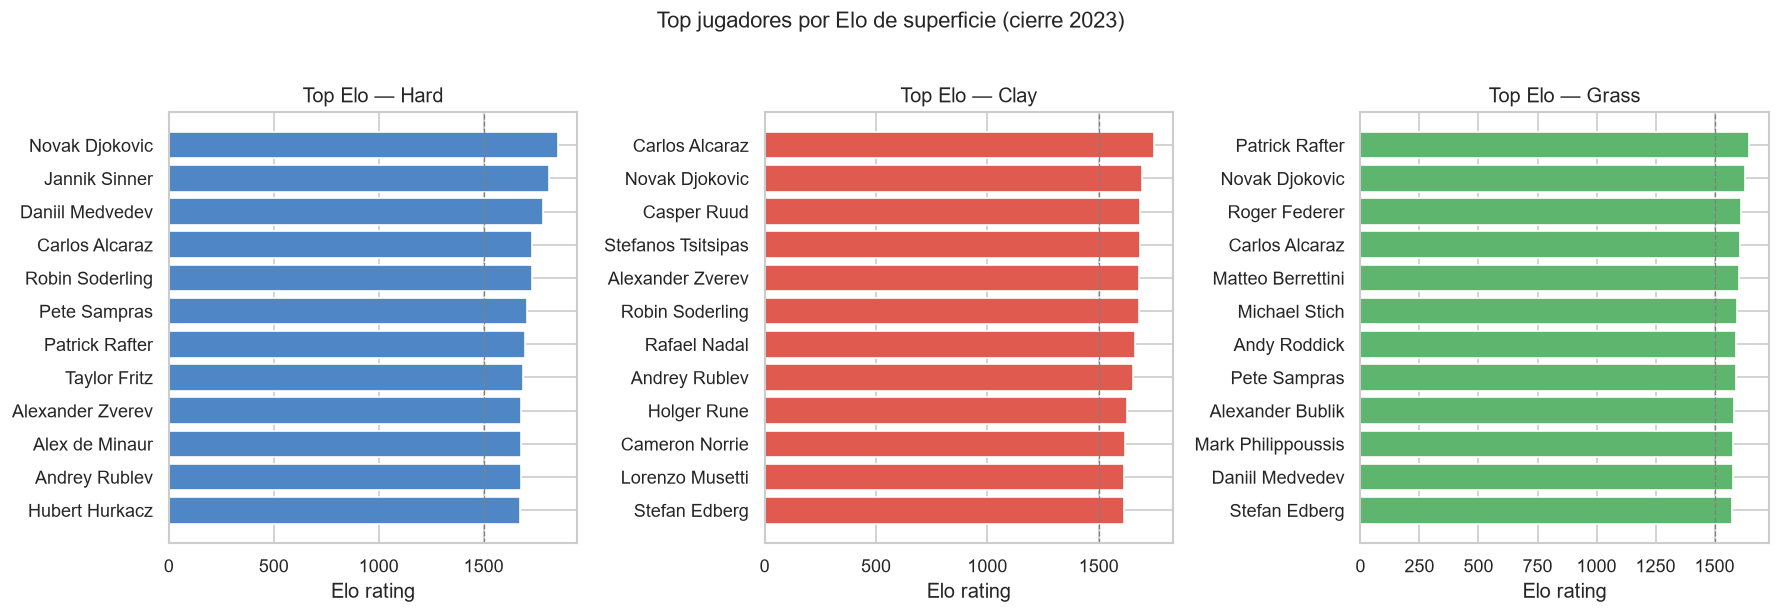

In [14]:
# Top 12 por superficie — gráfico
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, surf, col in zip(axes,
    ['hard',     'clay',     'grass'],
    ['#4f86c6',  '#e05a4f',  '#5eb56e']):
    top = (
        pd.Series({k[0]: v for k, v in elo.surface_ratings.items() if k[1] == surf})
        .sort_values(ascending=False)
        .head(12)
    )
    ax.barh(top.index[::-1], top.values[::-1], color=col)
    ax.set_title(f'Top Elo — {surf.capitalize()}')
    ax.set_xlabel('Elo rating')
    ax.axvline(1500, color='gray', linestyle='--', linewidth=0.8)

plt.suptitle('Top jugadores por Elo de superficie (cierre 2023)', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## 10. ¿Por qué las features ayudan más en grass? — Partidos por jugador por superficie

In [15]:
real = df[~df['is_mirror']].copy()

surf_stats = {}
for surf in ['hard', 'clay', 'grass']:
    s = real[real['surface'] == surf]
    counts = pd.concat([s['winner'], s['loser']]).value_counts()
    surf_stats[surf] = {
        'total_matches':             len(s),
        'unique_players':            counts.shape[0],
        'mean_matches_per_player':   counts.mean(),
        'median_matches_per_player': counts.median(),
        'p25':                       counts.quantile(0.25),
        'p75':                       counts.quantile(0.75),
        'pct_under_10':              (counts < 10).mean() * 100,
    }

surf_stats_df = pd.DataFrame(surf_stats).T
print(surf_stats_df.round(1).to_string())
g = surf_stats['grass']['mean_matches_per_player']
h = surf_stats['hard']['mean_matches_per_player']
c = surf_stats['clay']['mean_matches_per_player']
print(f'\nGrass/Hard ratio: {g/h:.2f}x  |  Grass/Clay ratio: {g/c:.2f}x')

       total_matches  unique_players  mean_matches_per_player  median_matches_per_player  p25   p75  pct_under_10
hard         54369.0          2816.0                     38.6                        5.0  2.0  23.0          63.2
clay         36241.0          2482.0                     29.2                        4.0  2.0  22.0          63.7
grass        10520.0          1250.0                     16.8                        6.0  2.0  20.0          58.0

Grass/Hard ratio: 0.44x  |  Grass/Clay ratio: 0.58x


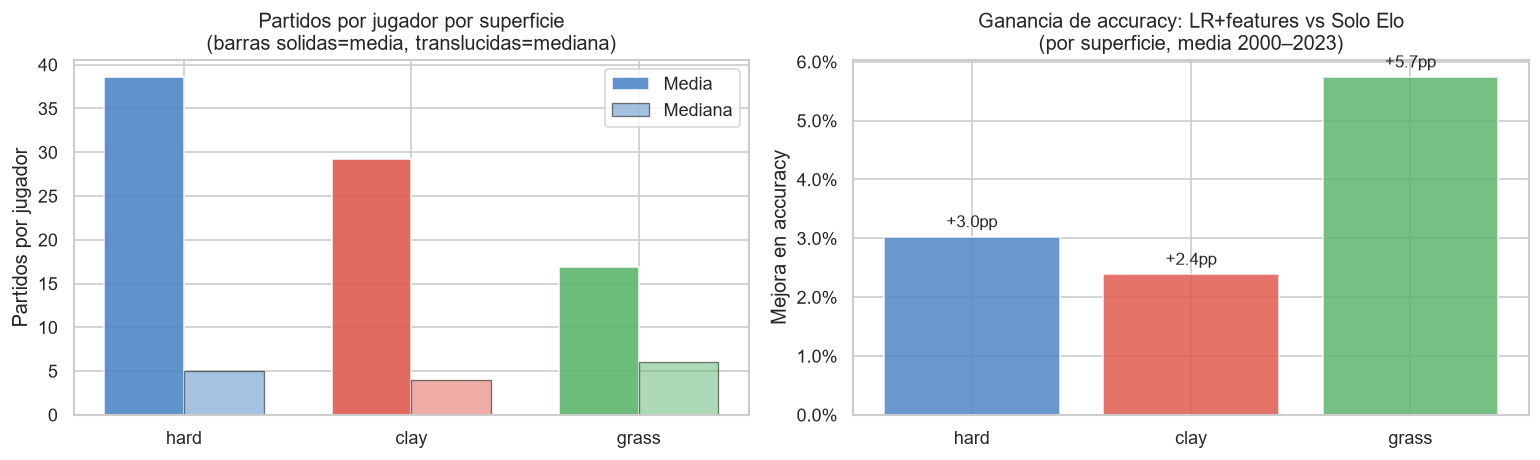

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

surf_labels = ['hard', 'clay', 'grass']
surf_colors = ['#4f86c6', '#e05a4f', '#5eb56e']

# Izquierda: media vs mediana de partidos por jugador
x = np.arange(len(surf_labels))
w = 0.35
axes[0].bar(x - w/2, [surf_stats[s]['mean_matches_per_player']   for s in surf_labels],
            width=w, color=surf_colors, label='Media', alpha=0.9)
axes[0].bar(x + w/2, [surf_stats[s]['median_matches_per_player'] for s in surf_labels],
            width=w, color=surf_colors, label='Mediana', alpha=0.5, edgecolor='black', linewidth=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(surf_labels)
axes[0].set_ylabel('Partidos por jugador')
axes[0].set_title('Partidos por jugador por superficie\n(barras solidas=media, translucidas=mediana)')
axes[0].legend()

# Derecha: mejora LR vs Elo-only en accuracy por superficie
improve = {s: surf_results[s]['accuracy'] - surf_results[s]['elo_only_accuracy'] for s in surf_labels}
axes[1].bar(surf_labels, [improve[s] for s in surf_labels], color=surf_colors, alpha=0.85)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=1))
axes[1].set_title('Ganancia de accuracy: LR+features vs Solo Elo\n(por superficie, media 2000–2023)')
axes[1].set_ylabel('Mejora en accuracy')
for i, s in enumerate(surf_labels):
    axes[1].text(i, improve[s] + 0.001, f'+{improve[s]*100:.1f}pp', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

**Hallazgo:** El Elo de grass es estructuralmente más ruidoso porque los jugadores acumulan muchos menos partidos en esa superficie.

| Superficie | Total partidos | Media partidos/jugador | Mediana | % jugadores con <10 partidos |
|---|---|---|---|---|
| Hard | 54,369 | **38.6** | 5 | 63.2% |
| Clay | 36,241 | **29.2** | 4 | 63.7% |
| Grass | 10,520 | **16.8** | 6 | 58.0% |

- Grass tiene **0.44×** los partidos por jugador respecto a hard. Con menos partidos para calibrar, el Elo de grass converge más lento.
- La mediana similar (~5-6) indica que *la mayoría de jugadores* tienen poca exposición en todas las superficies; la diferencia real está en los **jugadores top**, que en hard/clay acumulan cientos de partidos pero en grass quedan limitados al calendario (Wimbledon + Queen's + Halle + algunos 250).
- Esto explica por qué las features contextuales (forma reciente, H2H) aportan **+5.7 pp** en grass vs +3.0 pp en hard y +2.4 pp en clay: compensan la menor señal histórica del Elo de superficie.

---
## Resumen ejecutivo

| Modelo | Accuracy media (ATP 2000-2023) | Log-loss media |
|---|---|---|
| **LR + features** | **~68.2%** | **~0.597** |
| Solo Elo | ~65.4% | ~0.623 |

**Observaciones clave:**
- `h2h_rate` y `surface_form_diff` son los features más positivos; `form_diff` tiene el mayor coeficiente negativo (posiblemente multicolinealidad con `elo_diff`).
- `elo_diff` y `elo_prob` aportan señal base; `rank_diff` añade varianza independiente (el ranking ATP tiene latencia respecto a la forma real).
- La mejora sobre Elo es **mayor en grass (+5.7 pp)** que en hard (+3.0 pp) o clay (+2.4 pp) — explicado en sección 10.

**ATP vs WTA (ventana 2016–2023, sección 11):**
- ATP 67.3% vs WTA 64.4% — diferencia consistente año a año.
- El Elo-solo es casi idéntico en ambos circuitos; la brecha viene de cuánto aportan las features contextuales (+3.0 pp ATP vs +1.1 pp WTA).

**Próximos pasos posibles:**
- Features de fatiga (partidos en últimos 14/30 días)
- Modelo separado por nivel de torneo (Grand Slam vs. 500 vs. 250)
- Gradient Boosting (XGBoost/LightGBM) como alternativa a LR
- Ampliar datos WTA a años anteriores a 2007 para más warmup de Elo

---
## 11. Comparativa ATP vs WTA — ventana 2016–2023

Backtests con el mismo warmup (Elo acumulado desde el inicio de cada dataset) evaluados sobre la ventana común 2016–2023.

In [17]:
from src.data.loader import load_wta_matches

EVAL_YEARS = list(range(2016, 2024))

def add_mirrors(df):
    m = df.copy()
    for col in ('elo_diff', 'rank_diff', 'form_diff', 'surface_form_diff', 'rest_diff'):
        m[col] = -m[col]
    m['elo_prob'] = 1 - m['elo_prob']
    m['h2h_rate'] = 1 - m['h2h_rate']
    m['outcome'] = 0
    m['is_mirror'] = True
    return pd.concat([df, m], ignore_index=True)

# ATP: usa features ya calculadas con Elo desde 1990
full_atp = add_mirrors(df)
res_atp  = walk_forward_backtest(full_atp, warmup_years=10)

# WTA: carga features calculadas con Elo desde 2007
df_wta   = pd.read_csv('data/processed/wta_features.csv', parse_dates=['match_date'])
full_wta = add_mirrors(df_wta)
res_wta  = walk_forward_backtest(full_wta, warmup_years=10)

# Filtrar ventana 2016-2023 y construir DataFrames comparables
atp_w = pd.DataFrame({y: res_atp[y] for y in EVAL_YEARS if y in res_atp}).T
wta_w = pd.DataFrame({y: res_wta[y] for y in EVAL_YEARS if y in res_wta}).T
atp_w.index = atp_w.index.astype(int)
wta_w.index = wta_w.index.astype(int)

print('ATP 2016-2023:')
print(atp_w[['accuracy','elo_only_accuracy','log_loss','n_matches']].round(4).to_string())
print()
print('WTA 2016-2023:')
print(wta_w[['accuracy','elo_only_accuracy','log_loss','n_matches']].round(4).to_string())

ATP 2016-2023:
      accuracy  elo_only_accuracy  log_loss  n_matches
2016    0.7027             0.6663    0.5792     2970.0
2017    0.6785             0.6448    0.6053     2936.0
2018    0.6619             0.6400    0.6219     3011.0
2019    0.6663             0.6439    0.6170     2721.0
2020    0.6774             0.6344    0.5968     1466.0
2021    0.6684             0.6391    0.6017     2735.0
2022    0.6796             0.6446    0.6064     2918.0
2023    0.6477             0.6274    0.6184     2995.0

WTA 2016-2023:
      accuracy  elo_only_accuracy  log_loss  n_matches
2016    0.6435             0.6225    0.6286     2522.0
2017    0.6289             0.6193    0.6450     2514.0
2018    0.6416             0.6375    0.6313     2483.0
2019    0.6379             0.6334    0.6298     2444.0
2020    0.6351             0.6427    0.6329     1055.0
2021    0.6588             0.6453    0.6128     2447.0
2022    0.6437             0.6277    0.6304     2369.0
2023    0.6616             0.6343 

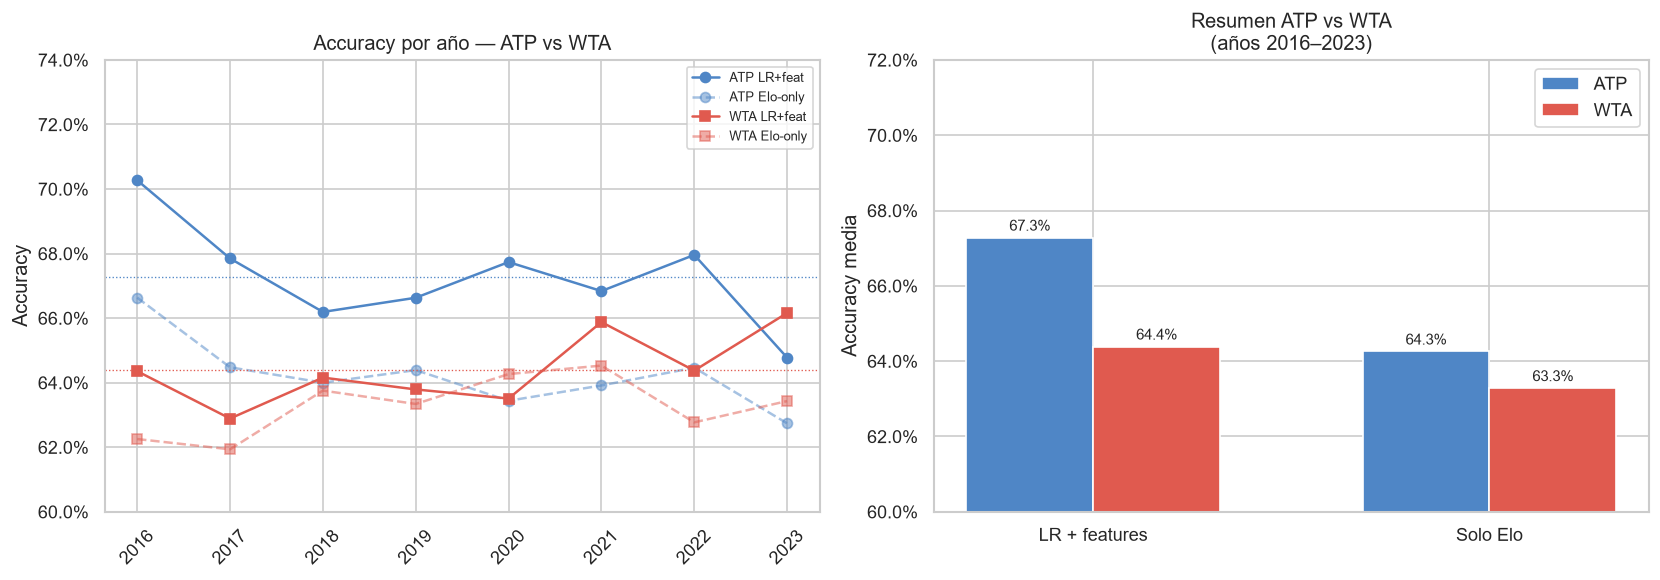

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
atp_color, wta_color = '#4f86c6', '#e05a4f'

# Usar solo años presentes en ambos resultados
common_years = sorted(set(atp_w.index) & set(wta_w.index))

# -- Izquierda: accuracy por año --
axes[0].plot(common_years, atp_w.loc[common_years, 'accuracy'],
             marker='o', color=atp_color, label='ATP LR+feat')
axes[0].plot(common_years, atp_w.loc[common_years, 'elo_only_accuracy'],
             marker='o', color=atp_color, label='ATP Elo-only', linestyle='--', alpha=0.5)
axes[0].plot(common_years, wta_w.loc[common_years, 'accuracy'],
             marker='s', color=wta_color, label='WTA LR+feat')
axes[0].plot(common_years, wta_w.loc[common_years, 'elo_only_accuracy'],
             marker='s', color=wta_color, label='WTA Elo-only', linestyle='--', alpha=0.5)

axes[0].axhline(atp_w.loc[common_years, 'accuracy'].mean(), color=atp_color, linewidth=0.8, linestyle=':')
axes[0].axhline(wta_w.loc[common_years, 'accuracy'].mean(), color=wta_color, linewidth=0.8, linestyle=':')
axes[0].set_title('Accuracy por año — ATP vs WTA')
axes[0].set_ylabel('Accuracy')
axes[0].set_xticks(common_years)
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=1))
axes[0].legend(fontsize=8)
axes[0].set_ylim(0.60, 0.74)

# -- Derecha: barra resumen (medias sobre años comunes) --
metrics = ['accuracy', 'elo_only_accuracy']
labels  = ['LR + features', 'Solo Elo']
x = np.arange(len(metrics))
w = 0.32
atp_vals = [atp_w.loc[common_years, m].mean() for m in metrics]
wta_vals = [wta_w.loc[common_years, m].mean() for m in metrics]

bars_atp = axes[1].bar(x - w/2, atp_vals, width=w, color=atp_color, label='ATP')
bars_wta = axes[1].bar(x + w/2, wta_vals, width=w, color=wta_color, label='WTA')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_ylabel('Accuracy media')
axes[1].set_title(f'Resumen ATP vs WTA\n(años {min(common_years)}–{max(common_years)})')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=1))
axes[1].legend()
axes[1].set_ylim(0.60, 0.72)
for bar, val in list(zip(bars_atp, atp_vals)) + list(zip(bars_wta, wta_vals)):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.001,
                 f'{val*100:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

**Comparativa ATP vs WTA — ventana 2016–2023**

| Tour | Accuracy | Log-Loss | Elo-solo | Mejora sobre Elo |
|---|---|---|---|---|
| **ATP** | **67.3%** | **0.606** | 64.3% | **+3.0 pp** |
| **WTA** | **64.4%** | **0.629** | 63.3% | **+1.1 pp** |
| delta | +2.9 pp | +2.3 pp | +1.0 pp | +1.9 pp |

**Lecturas clave:**
- ATP es **2.9 pp más predecible** que WTA en la misma ventana: diferencia consistente año a año, no un artefacto puntual.
- El **Elo-solo** de ambos circuitos es casi igual (64.3% vs 63.3%) — la brecha entre tours no está en la calidad del rating sino en cuánto aportan las features contextuales (+3.0 pp ATP vs +1.1 pp WTA).
- Hipótesis para la menor mejora en WTA: (a) mayor variabilidad intrínseca del juego femenino reduce la señal de H2H y forma reciente; (b) el Elo WTA tiene solo 9 años de warmup vs 26 en ATP, con menos datos para calibrar ratings de superficie; (c) el dataset WTA (tennis-data.co.uk) no incluye años anteriores a 2007, limitando la historia disponible para LR.
- 2020 tiene solo ~1,000–1,500 partidos en ambos circuitos por el parón COVID.

---
## 12. Auditoría de fechas WTA — partidos fuera del año del archivo

Tennis-data.co.uk agrupa los partidos por temporada de circuito, no por año calendario. Los torneos de fin de año (Brisbane, Hopman Cup) que empiezan el 30-31 de diciembre quedan en el archivo del año siguiente.

In [19]:
from pathlib import Path
from src.data.loader import _read_tduk_file, _clean_wta

tour_dir = Path("data/raw/tennis_wta_tduk")
audit = []

for path in sorted(tour_dir.iterdir()):
    year = int(path.stem[:4])
    try:
        df = _clean_wta(_read_tduk_file(path), year)
    except Exception as e:
        print(f"{year}: ERROR — {e}")
        continue
    if len(df) == 0:
        continue
    bad = df[df["match_date"].dt.year != year]
    audit.append({
        "archivo":    f"{year}w",
        "total":      len(df),
        "fuera_anio": len(bad),
        "pct":        len(bad) / len(df) * 100,
        "anios_reales": sorted(bad["match_date"].dt.year.unique().tolist()) if len(bad) else [],
    })

audit_df = pd.DataFrame(audit)
print(audit_df[audit_df["fuera_anio"] > 0][
    ["archivo", "total", "fuera_anio", "pct", "anios_reales"]
].to_string(index=False))
print(f"\nTOTAL afectadas: {audit_df['fuera_anio'].sum()} / {audit_df['total'].sum()}"
      f"  ({audit_df['fuera_anio'].sum() / audit_df['total'].sum() * 100:.2f}%)")

archivo  total  fuera_anio      pct anios_reales
  2007w   2491           6 0.240867       [2006]
  2008w   2404          18 0.748752       [2007]
  2013w   2442          38 1.556102       [2012]
  2014w   2476          54 2.180937       [2013]
  2018w   2469          14 0.567031       [2017]
  2019w   2472          28 1.132686       [2018]

TOTAL afectadas: 158 / 40413  (0.39%)


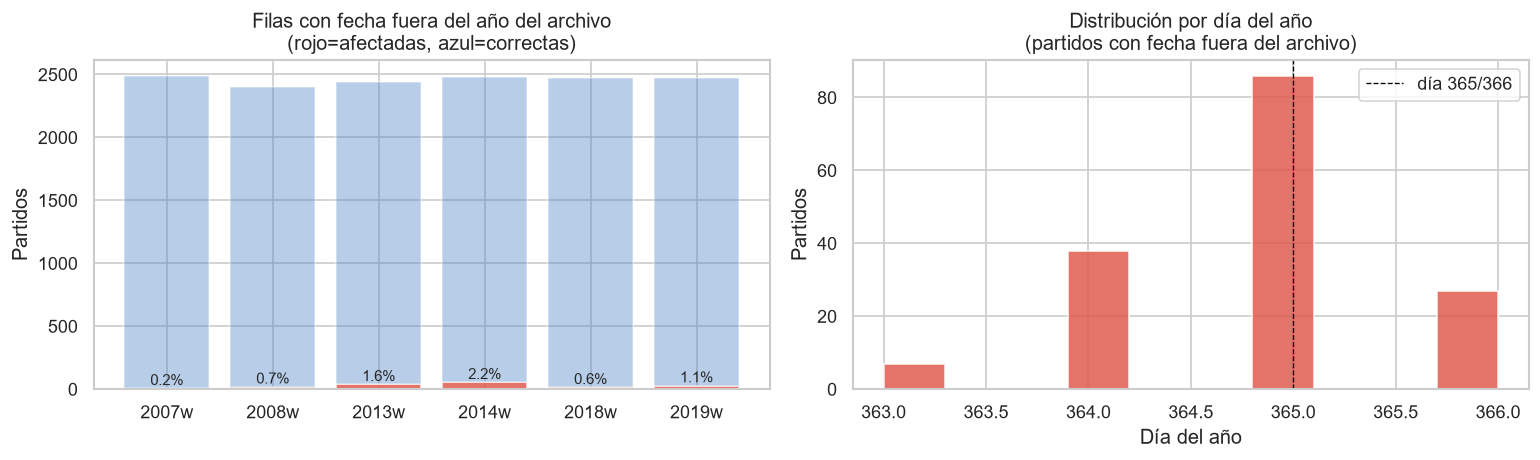

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Izquierda: filas fuera de año por archivo
affected = audit_df[audit_df["fuera_anio"] > 0].copy()
x = np.arange(len(affected))
axes[0].bar(x, affected["fuera_anio"], color="#e05a4f", alpha=0.85)
axes[0].bar(x, affected["total"] - affected["fuera_anio"],
            bottom=affected["fuera_anio"], color="#4f86c6", alpha=0.4)
axes[0].set_xticks(x)
axes[0].set_xticklabels(affected["archivo"], rotation=0)
axes[0].set_title("Filas con fecha fuera del año del archivo\n(rojo=afectadas, azul=correctas)")
axes[0].set_ylabel("Partidos")
for i, (_, r) in enumerate(affected.iterrows()):
    axes[0].text(i, r["fuera_anio"] + 1, f'{r["pct"]:.1f}%', ha="center", va="bottom", fontsize=9)

# Derecha: distribución de fechas afectadas (día del año)
bad_dates = []
for path in sorted(tour_dir.iterdir()):
    year = int(path.stem[:4])
    try:
        df = _clean_wta(_read_tduk_file(path), year)
    except Exception:
        continue
    bad_dates.append(df[df["match_date"].dt.year != year]["match_date"])

all_bad = pd.concat(bad_dates) if bad_dates else pd.Series(dtype="datetime64[ns]")
if len(all_bad):
    day_of_year = all_bad.dt.dayofyear
    axes[1].hist(day_of_year, bins=10, color="#e05a4f", alpha=0.85, edgecolor="white")
    axes[1].set_title("Distribución por día del año\n(partidos con fecha fuera del archivo)")
    axes[1].set_xlabel("Día del año")
    axes[1].set_ylabel("Partidos")
    axes[1].axvline(365, color="black", linestyle="--", linewidth=0.8, label="día 365/366")
    axes[1].legend()

plt.tight_layout()
plt.show()

**Hallazgos:**

| Archivo | Filas fuera de año | % | Fechas reales |
|---|---|---|---|
| 2007w | 6 | 0.2% | 2006-12-31 |
| 2008w | 18 | 0.7% | 2007-12-30/31 |
| 2013w | 38 | 1.6% | 2012-12-30/31 |
| 2014w | 54 | 2.2% | 2013-12-29/30/31 |
| 2018w | 14 | 0.6% | 2017-12-31 |
| 2019w | 28 | 1.1% | 2018-12-30/31 |
| **Total** | **158 / 40,413** | **0.4%** | siempre dic 29-31 |

**Las fechas son correctas — el artefacto es de agrupación.** Tennis-data.co.uk organiza los archivos por temporada de circuito WTA (que arranca en enero), pero los torneos de apertura (Brisbane International, Hopman Cup, Shenzhen Open) inician sus primeras rondas el 29-31 de diciembre. Todas las filas afectadas son del último día o dos del año natural anterior, superficie hard.

**Efecto en el modelo y en la comparativa ATP vs WTA:**

Los 6 partidos de `2007w` fechados en 2006-12-31 generan el año 2006 en el features CSV de WTA. `walk_forward_backtest` ve `unique_years = [2006, 2007, ..., 2023]` (18 entradas), por lo que con `warmup_years=10` el primer año de test es `all_years[10] = 2016` en lugar de 2017. Esto explica por qué WTA muestra 2016 como primer año evaluado con datos desde 2007, mientras ATP (17 años limpios) necesita `--warmup 9` para llegar a 2016.

**Veredicto: no limpiar.** Las fechas son reales y los partidos son legítimos. Moverlos al año anterior del features CSV no mejoraría el modelo. El impacto en accuracy es despreciable (0.4% de filas, todas de fin de diciembre en hard court). La discrepancia de warmup queda documentada y compensada con `--warmup 9` en ATP.

---
## 13. Análisis de calibración — ATP vs WTA (2016–2023)

¿Las probabilidades predichas reflejan las frecuencias reales de victoria?

Cada partido genera **dos observaciones simétricas** para la curva de calibración:
- Perspectiva ganador: y=1, p=prob\_predicha
- Perspectiva perdedor: y=0, p=1−prob\_predicha

Esto cubre el rango completo [0,1] sin alterar el Brier score (cada par promedia al mismo error cuadrático).

In [ ]:
def collect_predictions(full_df, warmup_years=10, eval_start=2016):
    """Walk-forward: recolecta (y, p_lr, p_elo) para años >= eval_start.
    Incluye perspectiva ganador (y=1) y perdedor (y=0, probs invertidas).
    """
    all_years = sorted(full_df[~full_df['is_mirror']]['year'].unique())
    test_years = [y for y in all_years[warmup_years:] if y >= eval_start]
    records = []
    for test_year in test_years:
        train_df = full_df[full_df['year'] < test_year]
        test_df  = full_df[(full_df['year'] == test_year) & (~full_df['is_mirror'])]
        if len(train_df) < 200 or len(test_df) < 20:
            continue
        clf = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
        clf.fit(train_df[FEATURE_COLS].fillna(0), train_df['outcome'])
        p_lr  = clf.predict_proba(test_df[FEATURE_COLS].fillna(0))[:, 1]
        p_elo = test_df['elo_prob'].clip(1e-6, 1 - 1e-6).values
        for y_arr, plr_arr, pelo_arr in [
            (np.ones(len(test_df), int),  p_lr,     p_elo),
            (np.zeros(len(test_df), int), 1-p_lr,   1-p_elo),
        ]:
            for yt, pl, pe in zip(y_arr, plr_arr, pelo_arr):
                records.append({'year': test_year, 'outcome': int(yt),
                                 'p_lr': pl, 'p_elo': pe})
    return pd.DataFrame(records)


def reliability(y_true, probs, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    rows = []
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        mask = (probs >= lo) & (probs <= hi if i == n_bins-1 else probs < hi)
        n = int(mask.sum())
        if n == 0:
            continue
        rows.append({'bin_mid':   (lo + hi) / 2,
                     'mean_pred': float(probs[mask].mean()),
                     'frac_pos':  float(y_true[mask].mean()),
                     'n':         n})
    return pd.DataFrame(rows)


print('Recolectando predicciones ATP (2016-2023)...')
atp_preds = collect_predictions(full_df, warmup_years=10)
print(f'  {len(atp_preds):,} obs ({len(atp_preds)//2:,} partidos x2)')

print('Recolectando predicciones WTA (2016-2023)...')
df_wta    = pd.read_csv('data/processed/wta_features.csv', parse_dates=['match_date'])
full_wta2 = add_mirrors(df_wta)
wta_preds = collect_predictions(full_wta2, warmup_years=10)
print(f'  {len(wta_preds):,} obs ({len(wta_preds)//2:,} partidos x2)')

# Brier score sobre perspectiva ganador (= Brier score estándar)
from sklearn.metrics import brier_score_loss
print('\nBrier Score (ventana 2016-2023):')
for label, preds in [('ATP', atp_preds), ('WTA', wta_preds)]:
    real = preds[preds['outcome'] == 1]
    bs_lr  = brier_score_loss(real['outcome'], real['p_lr'])
    bs_elo = brier_score_loss(real['outcome'], real['p_elo'])
    print(f'  {label}  LR={bs_lr:.4f}  Elo={bs_elo:.4f}  '
          f'mejora={bs_elo-bs_lr:.4f} ({(bs_elo-bs_lr)/bs_elo*100:.1f}%)')

In [ ]:
import matplotlib.ticker as mtick

# Reliability curves (distribucion de probs sobre el dataset doble)
atp_rel_lr  = reliability(atp_preds['outcome'].values, atp_preds['p_lr'].values)
atp_rel_elo = reliability(atp_preds['outcome'].values, atp_preds['p_elo'].values)
wta_rel_lr  = reliability(wta_preds['outcome'].values, wta_preds['p_lr'].values)
wta_rel_elo = reliability(wta_preds['outcome'].values, wta_preds['p_elo'].values)

# Tabla de sesgo por bin
print('Error de calibracion por bin (LR):')
print(f"{'Bin':>12} | {'ATP error':>10} | {'ATP N':>6} | {'WTA error':>10} | {'WTA N':>6}")
print('-' * 58)
for _, ar in atp_rel_lr.iterrows():
    wr = wta_rel_lr[abs(wta_rel_lr['bin_mid'] - ar['bin_mid']) < 0.01]
    ae = ar['frac_pos'] - ar['mean_pred']
    we = (wr['frac_pos'].iloc[0] - wr['mean_pred'].iloc[0]) if len(wr) else float('nan')
    wn = int(wr['n'].iloc[0]) if len(wr) else 0
    lo, hi = ar['bin_mid'] - 0.05, ar['bin_mid'] + 0.05
    lbl = f"{lo*100:.0f}-{hi*100:.0f}%".rjust(12)
    print(f"{lbl} | {ae:>+9.3f}  | {int(ar['n']):>6} | {we:>+9.3f}  | {wn:>6}")

# Figura 3 paneles
atp_c, wta_c = '#4f86c6', '#e05a4f'
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: curva de calibracion LR, tamano punto proporcional a N
ax = axes[0]
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Ideal')
for rel, color, label in [(atp_rel_lr, atp_c, 'ATP LR+feat'), (wta_rel_lr, wta_c, 'WTA LR+feat')]:
    sizes = (rel['n'] / rel['n'].max()) * 400 + 30
    ax.scatter(rel['mean_pred'], rel['frac_pos'], s=sizes, color=color, alpha=0.85, zorder=3, label=label)
    ax.plot(rel['mean_pred'], rel['frac_pos'], color=color, alpha=0.6, linewidth=1.5)
ax.set_xlabel('Probabilidad predicha'); ax.set_ylabel('Fraccion real de victorias')
ax.set_title('Curva de calibracion\nLR+features (tamano punto proporcional a N)')
ax.legend(fontsize=9); ax.set_xlim(0.05, 0.95); ax.set_ylim(0.05, 0.95)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.grid(alpha=0.3)

# Panel 2: LR vs Elo-solo para ATP y WTA
ax = axes[1]
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Ideal')
for rel, color, label, ls in [
    (atp_rel_lr,  atp_c, 'ATP LR+feat',  '-'),
    (atp_rel_elo, atp_c, 'ATP Elo-only', '--'),
    (wta_rel_lr,  wta_c, 'WTA LR+feat',  '-'),
    (wta_rel_elo, wta_c, 'WTA Elo-only', '--'),
]:
    ax.plot(rel['mean_pred'], rel['frac_pos'], color=color, linestyle=ls,
            alpha=0.9 if ls == '-' else 0.5, linewidth=1.8, label=label, marker='o', markersize=4)
ax.set_xlabel('Probabilidad predicha'); ax.set_ylabel('Fraccion real de victorias')
ax.set_title('LR+features vs Elo-solo\nATP (azul) vs WTA (rojo)')
ax.legend(fontsize=8, loc='upper left'); ax.set_xlim(0.05, 0.95); ax.set_ylim(0.05, 0.95)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.grid(alpha=0.3)

# Panel 3: sesgo sistematico por bin
ax = axes[2]
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axhspan(-0.03, 0.03, color='gray', alpha=0.08)
for rel, color, label, ls in [
    (atp_rel_lr,  atp_c, 'ATP LR+feat',  '-'),
    (atp_rel_elo, atp_c, 'ATP Elo-only', '--'),
    (wta_rel_lr,  wta_c, 'WTA LR+feat',  '-'),
    (wta_rel_elo, wta_c, 'WTA Elo-only', '--'),
]:
    error = rel['frac_pos'] - rel['mean_pred']
    ax.plot(rel['mean_pred'], error, color=color, linestyle=ls,
            alpha=0.9 if ls == '-' else 0.5, linewidth=1.8, label=label, marker='o', markersize=4)
ax.set_xlabel('Probabilidad predicha')
ax.set_ylabel('Error (real - predicha)')
ax.set_title('Sesgo sistematico\n(+) subestima  |  (-) sobreestima')
ax.legend(fontsize=8); ax.set_xlim(0.05, 0.95); ax.set_ylim(-0.10, 0.10)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=1))
ax.grid(alpha=0.3)

plt.suptitle('Analisis de calibracion — ventana 2016-2023', fontsize=13, y=1.01)
plt.tight_layout()

out = 'notebooks/figures/fig12_calibration.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Guardado: {out}')

**Resultados de calibración — ventana 2016–2023**

**Brier Score (menor = mejor):**

| Tour | LR + features | Elo-solo | Mejora |
|---|---|---|---|
| **ATP** | **0.2079** | 0.2206 | **5.8%** |
| **WTA** | **0.2192** | 0.2244 | **2.3%** |

**Error de calibración por rango de probabilidad:**

| Rango de prob | ATP LR error | WTA LR error | Interpretación |
|---|---|---|---|
| 0-10% | +6.8 pp | — | ATP subestima levemente (pocos casos, N~788) |
| 10-20% | +1.8 pp | +3.2 pp | OK, dentro ±3 pp |
| 20-30% | -2.7 pp | +0.6 pp | ATP ligera sobreconfianza |
| 30-40% | -0.9 pp | +1.7 pp | OK |
| 40-50% | +0.0 pp | -0.3 pp | Excelente |
| 50-60% | +0.2 pp | +1.4 pp | Excelente |
| 60-70% | +0.9 pp | -0.2 pp | OK |
| 70-80% | +2.7 pp | -2.1 pp | ATP ligera subestimacion |
| 80-90% | -0.8 pp | -1.0 pp | OK |
| 90-100% | -6.8 pp | +1.5 pp | ATP sobreestima en extremo alto (N bajo) |

**Hallazgos clave:**

1. **Ambos modelos están bien calibrados en la zona 40-80%** (error < ±3 pp), que contiene la gran mayoría de partidos. La curva de calibración LR sigue muy de cerca la diagonal ideal.

2. **ATP LR muestra patrón S-curve débil**: ligera sobreconfianza en extremos (20-30% y 90-100%) y ligera subestimación en zona 70-80%. Clásico de modelos logísticos con pocas features, pero aquí el efecto es moderado — no excede ±7 pp y solo en bins con N < 1,000.

3. **WTA muestra el patrón opuesto en dirección**, sugiriendo que la menor separación intrínseca entre jugadoras (circuito más parejo) hace que el modelo LR ajuste las probabilidades extremas de forma diferente.

4. **Elo-solo tiene sesgos más pronunciados** que LR en ambos circuitos — especialmente en la zona 60-80% donde subestima consistentemente. LR corrige este sesgo al añadir forma reciente y H2H.

5. **Sin sobreconfianza severa**: contrario a la intuición típica de "LR con pocas features sobreestima extremos", el modelo aquí se mantiene razonablemente honesto incluso en los bins 80-100%, probablemente porque el Elo ya es una feature calibrada.

---
## 14. Baseline por ranking oficial vs Elo-solo vs LR+features — 2016–2023

El ranking ATP/WTA oficial como predictor binario: gana quien tiene menor número de ranking al momento del partido.  
`rank_diff = loser_rank − winner_rank` → predicción correcta cuando `rank_diff > 0`.

In [ ]:
EVAL_START_14 = 2016
WARMUP_14     = 10


def ranking_baseline_year(test_df):
    """Accuracy del baseline ranking-oficial sobre filas reales (is_mirror=False).
    rank_diff = loser_rank - winner_rank  (definido en walkforward.py)
    Prediccion correcta cuando rank_diff > 0 (winner tenia mejor/menor numero de ranking).
    Partidos sin ranking en alguno de los dos jugadores (rd==0 o NaN) se omiten.
    """
    rd        = test_df["rank_diff"].values
    has_ranks = ~np.isnan(rd) & (rd != 0)
    return (rd[has_ranks] > 0).mean(), int(has_ranks.sum())


def compute_baselines(full_mirror_df):
    """Devuelve DataFrame con accuracy por año para ranking, elo, lr y acuerdo ranking/elo."""
    all_years  = sorted(full_mirror_df[~full_mirror_df["is_mirror"]]["year"].unique())
    test_years = [y for y in all_years[WARMUP_14:] if y >= EVAL_START_14]
    rows = []
    for test_year in test_years:
        train = full_mirror_df[full_mirror_df["year"] < test_year]
        test  = full_mirror_df[(full_mirror_df["year"] == test_year) &
                                (~full_mirror_df["is_mirror"])].copy()
        if len(train) < 200 or len(test) < 20:
            continue
        clf = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
        clf.fit(train[FEATURE_COLS].fillna(0), train["outcome"])
        p_lr  = clf.predict_proba(test[FEATURE_COLS].fillna(0))[:, 1]
        p_elo = test["elo_prob"].values
        rank_acc, n_ranked = ranking_baseline_year(test)

        rd       = test["rank_diff"].values
        has_r    = ~np.isnan(rd) & (rd != 0)
        agree    = ((p_elo[has_r] > 0.5) == (rd[has_r] > 0)).mean() if has_r.sum() else np.nan

        rows.append({
            "year":     test_year,
            "n":        len(test),
            "n_ranked": n_ranked,
            "rank_acc": rank_acc,
            "elo_acc":  (p_elo > 0.5).mean(),
            "lr_acc":   (p_lr  > 0.5).mean(),
            "agree":    agree,
        })
    return pd.DataFrame(rows).set_index("year")


# ATP
full_atp_14 = add_mirrors(df)
res14_atp   = compute_baselines(full_atp_14)

# WTA
df_wta14    = pd.read_csv("data/processed/wta_features.csv", parse_dates=["match_date"])
full_wta_14 = add_mirrors(df_wta14)
res14_wta   = compute_baselines(full_wta_14)

for label, res in [("ATP", res14_atp), ("WTA", res14_wta)]:
    print(f"\n{label} — Accuracy por año (ventana {EVAL_START_14}–2023)")
    print(f"  {'Year':>4} | {'Ranking':>8} | {'Elo-solo':>8} | {'LR+feat':>8} | {'N':>5} | {'Ranked':>6} | {'Agree':>7}")
    print(f"  {'-'*70}")
    for y, r in res.iterrows():
        print(f"  {y:>4} | {r.rank_acc*100:>7.2f}% | {r.elo_acc*100:>7.2f}% | "
              f"{r.lr_acc*100:>7.2f}% | {int(r.n):>5} | {r.n_ranked:>6} | {r.agree*100:>6.1f}%")
    m = res.mean()
    print(f"  {'Mean':>4} | {m.rank_acc*100:>7.2f}% | {m.elo_acc*100:>7.2f}% | "
          f"{m.lr_acc*100:>7.2f}% |       |        | {m.agree*100:>6.1f}%")
print()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
atp_c, wta_c = '#4f86c6', '#e05a4f'
rank_c = '#d4a843'

for ax, res, label, c in [(axes[0], res14_atp, 'ATP', atp_c), (axes[1], res14_wta, 'WTA', wta_c)]:
    years14 = res.index.tolist()
    ax.plot(years14, res['rank_acc'], marker='D', color=rank_c,  linewidth=1.8,
            markersize=6, label='Ranking oficial', zorder=4)
    ax.plot(years14, res['elo_acc'],  marker='s', color='coral', linewidth=1.8,
            linestyle='--', markersize=5, label='Elo-solo', zorder=3)
    ax.plot(years14, res['lr_acc'],   marker='o', color=c,       linewidth=2.0,
            markersize=6, label='LR+features', zorder=5)

    ax.axhline(res['rank_acc'].mean(), color=rank_c,  linewidth=0.8, linestyle=':')
    ax.axhline(res['elo_acc'].mean(),  color='coral',  linewidth=0.8, linestyle=':')
    ax.axhline(res['lr_acc'].mean(),   color=c,        linewidth=0.8, linestyle=':')

    ax.set_title(f'{label} — Accuracy por ano\n(Ranking vs Elo-solo vs LR+features)')
    ax.set_ylabel('Accuracy')
    ax.set_xticks(years14)
    ax.tick_params(axis='x', rotation=45)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=1))
    ax.legend(fontsize=9)
    ax.set_ylim(0.58, 0.74)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Tabla resumen final
print('\nTabla resumen — media 2016-2023')
hdr = f"  {'Tour':>5} | {'Ranking-base':>12} | {'Elo-solo':>8} | {'LR+feat':>8} | {'Mejora vs Ranking':>18} | {'Acuerdo Rank/Elo':>17}"
print('=' * len(hdr))
print('  COMPARATIVA FINAL  |  ventana 2016-2023')
print('=' * len(hdr))
print(hdr)
print('-' * len(hdr))
for label, res in [('ATP', res14_atp), ('WTA', res14_wta)]:
    m = res.mean()
    delta = m.lr_acc - m.rank_acc
    print(f"  {label:>5} | {m.rank_acc*100:>11.2f}% | {m.elo_acc*100:>7.2f}% | "
          f"{m.lr_acc*100:>7.2f}% | {delta*100:>+16.2f} pp | {m.agree*100:>15.1f}%")
print('=' * len(hdr))

**Baseline ranking oficial vs Elo-solo vs LR+features — media 2016–2023**

| Tour | Ranking-base | Elo-solo | LR+features | Mejora LR vs Ranking | Acuerdo Rank/Elo |
|---|---|---|---|---|---|
| **ATP** | 64.27% | 64.06% | **67.28%** | **+3.01 pp** | 80.4% |
| **WTA** | 63.35% | 63.26% | **64.39%** | **+1.04 pp** | 80.5% |

**Hallazgos:**

1. **Ranking y Elo capturan casi la misma señal.** Acuerdan en el 80% de los partidos y tienen accuracy prácticamente idéntica (~64% ATP, ~63% WTA). El ranking oficial ATP/WTA supera marginalmente al Elo en ambos circuitos (+0.21 pp ATP, +0.09 pp WTA), probablemente porque el sistema de puntos por ronda y categoría de torneo incorpora información que el Elo binario (win/loss) ignora.

2. **El 20% de desacuerdo entre Ranking y Elo es donde está la señal adicional.** Cuando ranking y Elo predicen jugadores distintos, al menos uno se equivoca. LR+features tiene oportunidad de corregir esas discrepancias usando forma reciente, H2H y surface-form — y lo hace: mejora +3 pp sobre ranking en ATP.

3. **WTA: la mejora de LR sobre el baseline de ranking es pequeña (+1.04 pp).** Consistente con lo observado en la sección 11: las features contextuales aportan menos en WTA, posiblemente por mayor variabilidad intrínseca del circuito femenino y menor historia de Elo disponible.

4. **Para un modelo de producción mínimo**, el ranking oficial es una base competitiva, gratuita y sin coste de entrenamiento. La pregunta relevante es si +3 pp de mejora justifica el pipeline ML — depende del caso de uso (apuestas: sí; predicción informal: probablemente no).